In [241]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl 
sns.set_theme(context = 'notebook', style='white')
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm
import statsmodels.tsa as tsa
from statsforecast.models import AutoARIMA
from statsforecast import StatsForecast
import statsmodels.tsa.seasonal as seasonal
import scipy.stats
import statsmodels.stats.diagnostic as diag
import torch
from lightning.pytorch.loggers import MLFlowLogger
from collections import namedtuple
import requests
from torch.utils.data import Dataset, DataLoader
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import lightning as L
from NBEATS import NBEATS
import mlflow
from torch import optim
from torch import nn
import os
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import requests

# Build a toy dataset to test RL model

## Noisy trends

In [242]:
N = 5000

trend = lambda x : np.arange(0,N)*x + N 
noise = lambda eps : np.random.normal(0, eps, N)

In [301]:
slopes = np.random.uniform(-0.5, 0.5, size = (11,))

assets = []
for s in slopes:
    asset = trend(s) + noise(10)
    assets.append(asset)
assets = np.array(assets).T
assets = np.expand_dims(assets, axis = -1)

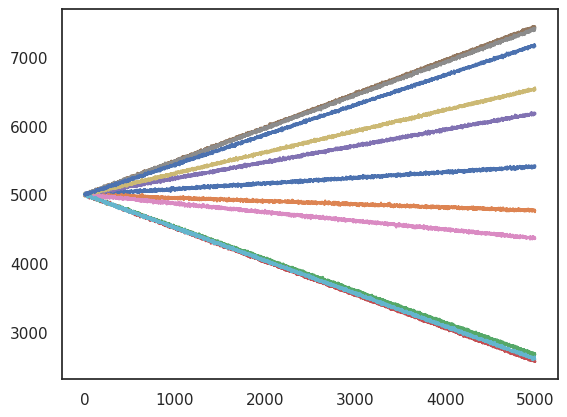

In [302]:
for a in range(11):
    plt.plot(assets[:,a])

In [303]:
class Data_portfolio(Dataset):
    def __init__(self, flag, input_len, split):
        super().__init__()
        self.flag = flag
        self.input_len = input_len
        self.split = split
        self.__read_data__()

    def __read_data__(self):
        data = assets
        data = torch.tensor(data)
        data = torch.permute(data, (2,1,0))
        self.split_test = self.split + 1/2*(1-self.split)
        self.split = int(self.split * data.shape[-1])
        
        self.test_split = int(self.split_test*data.shape[-1])
        if self.flag == 'train':
            self.data = data[:,:,:self.split]
        elif self.flag == 'val':
            self.data = data[:,:,self.split:self.test_split]
        elif self.flag == 'test':
            self.data = data[:,:,self.test_split:]
    def __getitem__(self, index):  
        seq_x =self.data[:,:,index:index+self.input_len]
        seq_x = seq_x
        seq_y = self.data[0,:,index+self.input_len]/self.data[0,:,index+self.input_len-1]
        seq_y = torch.cat((torch.tensor([1]), seq_y), dim = 0)
        return seq_x, seq_y
    
    def __len__(self):
        return self.data.shape[-1]-self.input_len-1

In [304]:
class DataModule_noval(L.LightningDataModule):
    def __init__(self, input_len, split, batch_size):
        self.split = split
        self.batch_size = batch_size
        self.input_len = input_len
        super().__init__()
        # self.save_hyperparameters()
    def setup(self, stage : str):
        if stage == 'fit' :
            self.dataset_train = Data_portfolio( flag = 'train', input_len=self.input_len, split = self.split)
            self.dataset_val = Data_portfolio( flag = 'val', input_len=self.input_len, split = self.split)
        if stage == 'test' :
            self.dataset_test = Data_portfolio(flag = 'test', input_len=self.input_len, split = self.split)
        
    def train_dataloader(self):
        return DataLoader(
        self.dataset_train,
        batch_size = self.batch_size,
        shuffle = True,
        num_workers = 3,
        drop_last = True)
    
    def val_dataloader(self):
        return DataLoader(
        self.dataset_val,
        batch_size = self.batch_size,
        shuffle = False,
        num_workers = 3,
        drop_last = True)
        
    def test_dataloader(self):
        return DataLoader(self.dataset_test, batch_size=self.batch_size, shuffle=False, num_workers=2, drop_last = True)

In [ ]:
class Model(nn.Module):
    def __init__(self, seq_len, batch_size):
        super(Model, self).__init__()
        self.layer = 3
        self.seq_len = seq_len
        self.conv = nn.Conv2d(in_channels=1, out_channels = 2, kernel_size=(1,3), stride = 1, padding = 'valid')
        self.dropout = nn.Dropout2d(0.5)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=2, out_channels=20, kernel_size=(1,seq_len-2), stride = 1, padding = 'valid')
        self.conv3 = nn.Conv2d(in_channels=20, out_channels=1, kernel_size=1, padding = 'valid')
        self.last_activ = nn.Softmax(dim = 1)
        self.dense = nn.Linear(11,12)

            
    def forward(self, x):
        self.means = x.mean(-1, keepdim=True).detach()
        x = x - self.means
        self.stdev = torch.sqrt(torch.var(x, dim=-1, keepdim=True, unbiased=False) + 1e-5)
        x /= self.stdev
        
        x = self.conv(x)
        x = self.relu(x) 
        x =self.dropout(x)

        x = self.conv2(x)
        x = self.relu(x)
        x =self.dropout(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = x.flatten(start_dim=1)
        x = self.dense(x)
        x = self.last_activ(x)
        return x


def var_init(model, std=0.5):
    for name, param in model.named_parameters():
        param.data.normal_(mean=0.0, std=0.5)

class LModel(L.LightningModule):
    def __init__(self, seq_len, batch_size):
        super().__init__()
        self.seq_len = seq_len
        self.batch_size = batch_size
        # self.model = NBEATS(1, seq_len, enc_in = 11)
        self.model = Model(seq_len, batch_size)
        var_init(self.model)
        self.save_hyperparameters()

    def training_step(self, batch, batch_idx):
        batch_x, batch_y = batch
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        outputs = self.model(batch_x)
        # outputs = torch.concatenate()
        loss = torch.mean(torch.log(torch.sum(outputs*batch_y, dim = 1)))
        APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y, dim = 1))))
        pv =  torch.sum(outputs * batch_y, dim = 1)
        sharpe_ratio = (torch.mean(pv)-1)/torch.std(pv)
        self.log('train_loss', loss, on_epoch = True)
        self.log('train_sharpe', sharpe_ratio)
        
        return loss 

    def validation_step(self, batch, batch_idx):
        batch_x, batch_y = batch
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        outputs = self.model(batch_x)
        loss = torch.mean(torch.log(torch.sum(outputs*batch_y, dim = 1)))
        APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y, dim = 1))))
        pv =  torch.sum(outputs * batch_y, dim = 1)
        sharpe_ratio = (torch.mean(pv)-1)/torch.std(pv)
        self.log('val_loss', loss)
        self.log('val_APV', APV)
        self.log('val_sharpe', sharpe_ratio)
        
        
    def test_step(self, batch, batch_idx):
        batch_x, batch_y = batch
        batch_x = batch_x.float()
        batch_y = batch_y.float()
        outputs = self.model(batch_x)
        reward = torch.mean(torch.log(torch.sum(outputs*batch_y, dim = 1)))
        APV = torch.exp(torch.sum(torch.log(torch.sum(outputs*batch_y, dim = 1))))
        pv =  torch.sum(outputs * batch_y, dim = 1)
        sharpe_ratio = (torch.mean(pv)-1)/torch.std(pv)
        self.log('test_reward', reward)
        self.log('test_APV', APV)
        self.log('test_sharpe', sharpe_ratio)
    def forward(self, x):
        return self.model(x)
            
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4, maximize = True)
        return optimizer


In [306]:
Lmodel = LModel(seq_len=50, batch_size=200)
data = DataModule_noval(input_len = 50, split= 0.7, batch_size = 200)

In [307]:
n_epochs = 100
logger =  MLFlowLogger(experiment_name = 'RL_proj', run_name = f'RL_run_naive', tracking_uri = os.getenv('MLFLOW_TRACKING_URI'), artifact_location = os.getenv('ARTIFACT_URI'))

trainer = L.Trainer(
                    devices = 1, accelerator = 'gpu',  max_epochs = n_epochs, logger = logger, log_every_n_steps=n_epochs//10, enable_progress_bar=True, callbacks=[EarlyStopping('val_loss', patience=5, mode='max')])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [308]:
trainer.fit(Lmodel, data)
trainer.test(Lmodel, data)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type  | Params | Mode 
----------------------------------------
0 | model | Model | 2.1 K  | train
----------------------------------------
2.1 K     Trainable params
0         Non-trainable params
2.1 K     Total params
0.008     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Epoch 99: 100%|██████████| 17/17 [00:00<00:00, 29.73it/s, v_num=cba3]       

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 17/17 [00:00<00:00, 26.67it/s, v_num=cba3]
🏃 View run RL_run_naive at: https://mlflow-public.models.cardoai.com/#/experiments/2815/runs/44c2b2af943249fda811aed3cba2cba3
🧪 View experiment at: https://mlflow-public.models.cardoai.com/#/experiments/2815


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 47.05it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_APV          │    0.9976339936256409     │
│        test_reward        │  -1.207141212944407e-05   │
│        test_sharpe        │   -0.006224398501217365   │
└───────────────────────────┴───────────────────────────┘

🏃 View run RL_run_naive at: https://mlflow-public.models.cardoai.com/#/experiments/2815/runs/44c2b2af943249fda811aed3cba2cba3
🧪 View experiment at: https://mlflow-public.models.cardoai.com/#/experiments/2815


[{'test_reward': -1.207141212944407e-05,
  'test_APV': 0.9976339936256409,
  'test_sharpe': -0.006224398501217365}]

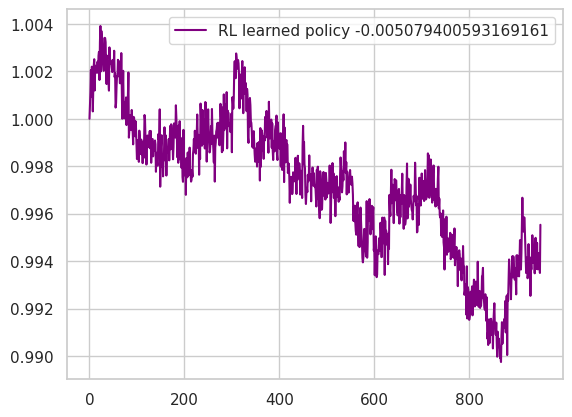

In [312]:
runid = mlflow.search_runs(experiment_ids=[2815], filter_string='tags.mlflow.runName = "RL_run_naive"')['run_id'][0]
path = f'./2815/{runid}/checkpoints/'
final_path = path + os.listdir(path)[0]
model = LModel.load_from_checkpoint(final_path)
data = assets
data = torch.tensor(data)
backtest = torch.permute(data, (2,1,0))
def backtest_by_strategy(data, strategy, seq_len, last_w = False):
    # lastw = torch.zeros((7))
    # lastw[0] = 1
    lastw = torch.ones((12))/12
    lastw = lastw.unsqueeze(0).to('cuda:0')
    log_mean =[]
    APV = [1]
    pvector = []
    w = []
    Y = []
    for i in range(1000-seq_len):
        x = data[:,:,i:i+seq_len]/ data[0,:,i+seq_len:i+seq_len+1].repeat((1,1,seq_len))
        y = (data[0,:,i+seq_len]/data[0,:,i+seq_len-1])
        y = torch.cat((torch.tensor([1]), y), dim = 0).to('cuda:0')
        if last_w:        
            new_w = strategy(x.unsqueeze(0).to('cuda:0'), lastw[:,1:].to('cuda:0'))
        else:
            new_w = strategy(x.unsqueeze(0).to('cuda:0').float())
        w.append(np.array(new_w.squeeze().cpu().detach()))
        Y.append(np.array(y.cpu().detach()))
        w_prime = (y * lastw).to('cuda:0')
        w_prime = w_prime/torch.sum(w_prime)
        c = 0.0
        mu = 1 - torch.sum(torch.abs(new_w - w_prime), dim=1) * c
        pv = torch.sum(new_w * y.to('cuda:0') * mu.to('cuda:0'))
        pvector.append(pv)
        log_mean.append(torch.mean(torch.log(torch.sum(new_w * y.to('cuda:0') * mu.to('cuda:0')))).item())
        APV.append(APV[-1]*torch.exp(torch.tensor(log_mean[-1])))
        lastw = new_w
    return APV, log_mean, torch.tensor(pvector), w, Y
model.eval()
APV, log_mean, pv, w, Y = backtest_by_strategy(backtest, model, model.seq_len, False)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'purple', label = f'RL learned policy {sharpe}')
plt.legend()

In [313]:
def simplex_proj(y):
    '''projection of y onto simplex. '''
    m = len(y)
    bget = False

    s = torch.sort(y, descending = True)[0]
    tmpsum = 0.

    for ii in range(m-1):
        tmpsum = tmpsum + s[ii]
        tmax = (tmpsum - 1) / (ii + 1)
        if tmax >= s[ii+1]:
            bget = True
            break

    if not bget:
        tmax = (tmpsum + s[m-1] - 1) / m

    return torch.maximum(torch.tensor(0), y-tmax)

## Define strategies
class buy_and_hold():
    def __init__(self, n):
        self.n = n
    def __call__(self, x, lastw = None):
        new_w = torch.zeros((12)).to('cuda:0')
        new_w[self.n] = 1
        return new_w.unsqueeze(0)

class UCRP():
    def __init__(self):
        pass
    
    def __call__(self, x, lastw = None):
        new_w = torch.ones((12)).to('cuda:0')
        new_w = new_w/torch.sum(new_w)
        return new_w.unsqueeze(0)

class PAMR():
    def __init__(self, epsilon, variant, C):
        self.epsilon = epsilon
        self.C = torch.tensor(C)
        self.variant = variant

    def __call__(self, x, lastw):
        last_rel_price = x[0,-1,:,-1]/x[0,-1,:,-2]
        last_rel_price = torch.cat((torch.tensor([1]).to('cuda:0'), last_rel_price), dim = 0)
        lastw = torch.cat((torch.tensor([1-torch.sum(lastw)]).to('cuda:0'), lastw.squeeze()), dim = 0)

        denom = torch.square(torch.norm(last_rel_price-torch.mean(last_rel_price)))
        diff = torch.dot(lastw.float(), last_rel_price.squeeze().float())- self.epsilon
        le = torch.maximum(torch.tensor(0), diff)

        if self.variant == 0:
            tau = le / denom
        elif self.variant == 1:
            tau = torch.minimum(self.C, le / denom)
        elif self.variant == 2:
            tau = le / (denom + 0.5 / self.C)
            
        tau = torch.minimum(torch.tensor(10000), tau)

        new_w = lastw - tau * (last_rel_price - torch.mean(last_rel_price))
        return simplex_proj(new_w).unsqueeze(0)
        

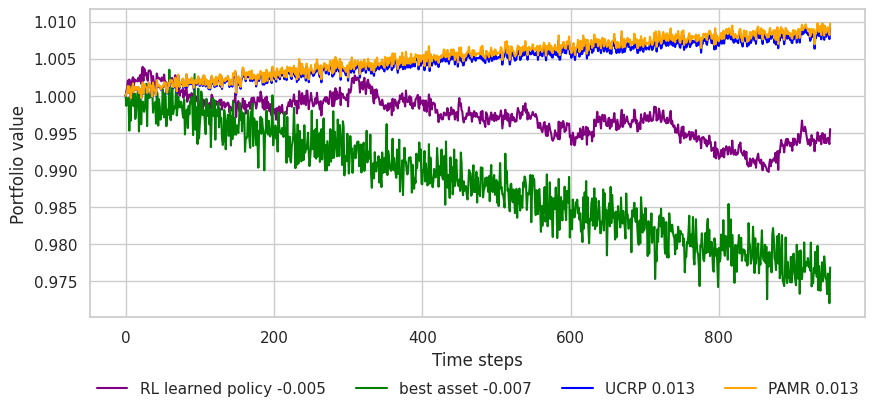

In [311]:
model.eval()
sns.set_style('whitegrid')
plt.figure(figsize=(10,4))
APV, log_mean, pv, w, _ = backtest_by_strategy(backtest, model, model.seq_len, False)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'purple', label = f'RL learned policy {sharpe:.3f}')
APV, log_mean, pv, _, _ = backtest_by_strategy(backtest, buy_and_hold(7), model.seq_len)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'green', label = f'best asset {sharpe:.3f}')
APV, log_mean, pv, _,_ = backtest_by_strategy(backtest, UCRP(), model.seq_len)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'blue', label = f'UCRP {sharpe:.3f}')
APV, log_mean, pv, _,_ = backtest_by_strategy(backtest, PAMR(0.95, 2, 0.5), model.seq_len, True)
sharpe = (torch.mean(pv)-1)/torch.std(pv)
plt.plot(APV, color = 'orange', label = f'PAMR {sharpe:.3f}')
plt.xlabel('Time steps')
plt.ylabel('Portfolio value')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol = 7, frameon = False)
plt.savefig('APV_plot_model',dpi = 300, transparent = True,  bbox_inches="tight")

/tmp/ipykernel_39811/1576266854.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


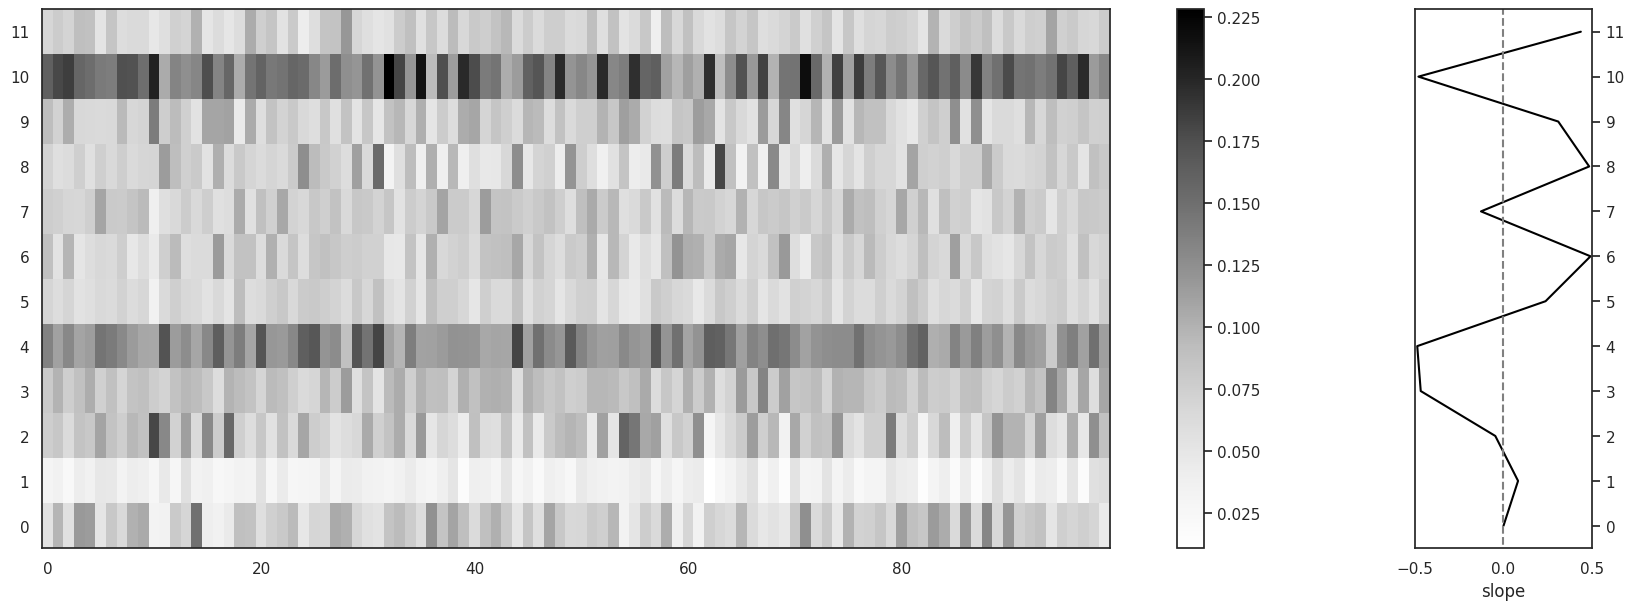

In [315]:
import matplotlib.gridspec as gridspec
sns.set_style('white')
fig = plt.figure(figsize = (20,7))
gs = gridspec.GridSpec(1, 2, width_ratios=[15, 2], wspace=0.05)
# Create second axes sharing the y-axis, positioned to the right
ax_matrix = fig.add_subplot(gs[0])
im = ax_matrix.imshow(np.array(w)[:100].T, cmap=plt.cm.Greys, aspect = 'auto')
plt.colorbar(im, ax = ax_matrix)

ax_curve = fig.add_subplot(gs[1], sharey=ax_matrix)
ax_curve.plot([0] + list(slopes), np.arange(np.array(w).shape[1]), color = 'black')

ax_curve.vlines(0, -2, 15, linestyles= '--', color ='grey')
ax_curve.set_ylim(-0.5,11.5)
ax_curve.set_xlim(-0.5,.5)
ax_curve.set_xlabel("Mean Value")
ax_curve.yaxis.tick_right()
ax_curve.yaxis.set_label_position("right")
ax_curve.set_xlabel('slope')
plt.yticks(range(12))
plt.tight_layout()

plt.savefig('weights_distrib_st001',dpi = 300, transparent = True)

(-0.5, 11.5)

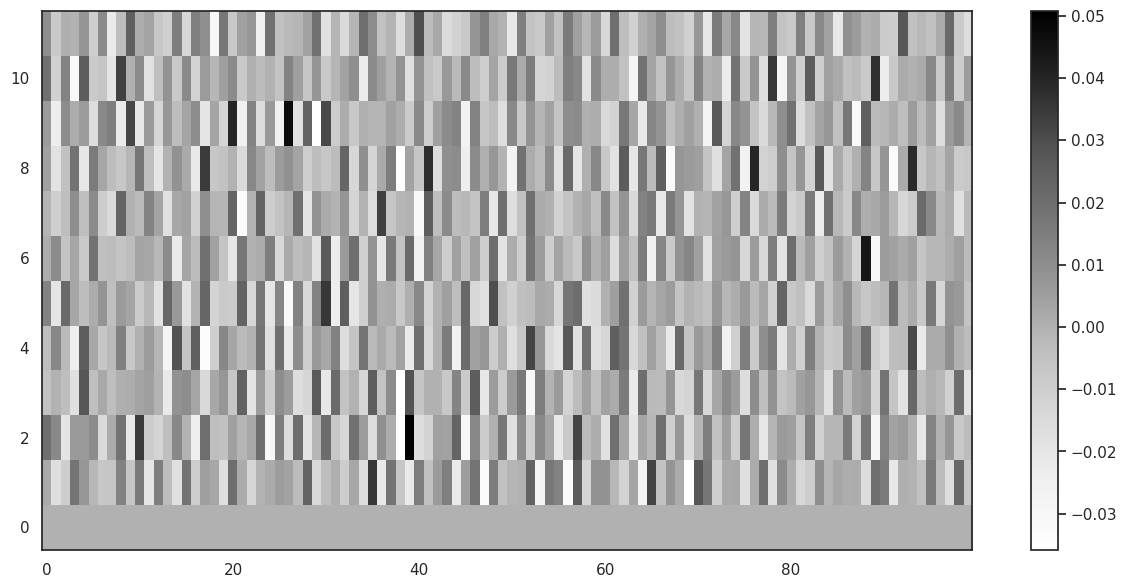

In [300]:
fig = plt.figure(figsize = (15,7))
im = plt.imshow(np.array(Y)[:100].T-1, cmap=plt.cm.Greys, aspect = 'auto')
plt.colorbar()
plt.ylim(-0.5,11.5)